In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os, time, shutil, pandas as pd
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import f1_score

PROJECT_DIR = "/content/drive/MyDrive/Concrete_defects_CNN_v2"
DATA_DIR = os.path.join(PROJECT_DIR, "Data")
DATASET_DIR = os.path.join(DATA_DIR, "dacl1k_raw")
CHECKPOINT_DIR = os.path.join(PROJECT_DIR, "checkpoints")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

assert os.path.exists(DATASET_DIR), f"{DATASET_DIR} not found — run 01_dataset_download.ipynb first."

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cpu":
    print("WARNING: no GPU attached. Runtime > Change runtime type > T4 GPU, reconnect, re-run.")

Mounted at /content/drive
Device: cuda


In [2]:
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [ ]:
LOCAL_DATASET_DIR = "/content/dacl1k_local"

def ensure_local_dataset(drive_dir, local_dir):
    if os.path.exists(local_dir):
        orig = sum(len(f) for _, _, f in os.walk(drive_dir))
        local = sum(len(f) for _, _, f in os.walk(local_dir))
        if local != orig:
            shutil.rmtree(local_dir)
        else:
            return
    shutil.copytree(drive_dir, local_dir)

ensure_local_dataset(DATASET_DIR, LOCAL_DATASET_DIR)
DATASET_DIR = LOCAL_DATASET_DIR

In [ ]:
csv_candidates = [f for f in os.listdir(DATASET_DIR) if f.endswith(".csv")]
CLEAN_CSV = os.path.join(DATASET_DIR, "annotations_clean.csv")
LABELS_CSV = CLEAN_CSV if os.path.exists(CLEAN_CSV) else os.path.join(DATASET_DIR, csv_candidates[0])
df = pd.read_csv(LABELS_CSV)

print("CSV:", LABELS_CSV)
print("Columns:", df.columns.tolist())

known_meta_cols = {"img_name", "img_path", "CLASSES", "CLASSES_N", "CLASSES_STRING",
                   "isStatusChanged", "split", "split_bikit", "split_type",
                   "N_Classes", "n_classes", "num_labels"}

label_cols = [c for c in df.columns
              if c not in known_meta_cols and pd.api.types.is_numeric_dtype(df[c])]

split_col = "split_type"
path_col = "img_path" if "img_path" in df.columns else "img_name"

print("label_cols:", label_cols)
print("split_col:", split_col, "| path_col:", path_col)

NUM_CLASSES = len(label_cols)
print("NUM_CLASSES:", NUM_CLASSES)

assert split_col in df.columns, "Could not find a split column. Check the Columns printed above."

CSV: /content/dacl1k_local/annotations_clean.csv
Columns: ['img_path', 'img_name', 'NoDamage', 'Crack', 'Efflorescence', 'Rust', 'Spallation', 'BarsExposed', 'CLASSES_STRING', 'CLASSES_N', 'split_type']
label_cols: ['NoDamage', 'Crack', 'Efflorescence', 'Rust', 'Spallation', 'BarsExposed']
split_col: split_type | path_col: img_path
NUM_CLASSES: 6


In [ ]:
IMG_SIZE = 224
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

class Dacl1kDataset(Dataset):
    def __init__(self, dataframe, dataset_dir, path_col, label_cols, transform):
        self.df = dataframe.reset_index(drop=True)
        self.dataset_dir = dataset_dir
        self.path_col = path_col
        self.label_cols = label_cols
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.dataset_dir, row[self.path_col].replace("dacl1k/", ""))
        img = Image.open(img_path).convert("RGB")
        img = self.transform(img)
        label = torch.tensor(row[self.label_cols].values.astype("float32"))
        return img, label

print("Unique values in split column:", df[split_col].unique())

def split_mask(series, keyword):
    return series.astype(str).str.lower().str.contains(keyword)

train_df = df[split_mask(df[split_col], "train")]
val_df   = df[split_mask(df[split_col], "val")]
test_df  = df[split_mask(df[split_col], "test")]
print(f"train={len(train_df)} val={len(val_df)} test={len(test_df)}")
assert len(train_df) > 0 and len(val_df) > 0 and len(test_df) > 0, \
    "One or more splits came back empty — check the unique values printed above and adjust split_mask keywords."

BATCH_SIZE = 32
NUM_WORKERS = 2          # was 0 — this was the main cause of the slow runs
PIN_MEMORY = device.type == "cuda"

train_dataset = Dacl1kDataset(train_df, DATASET_DIR, path_col, label_cols, train_transform)
val_dataset   = Dacl1kDataset(val_df,   DATASET_DIR, path_col, label_cols, eval_transform)
test_dataset  = Dacl1kDataset(test_df,  DATASET_DIR, path_col, label_cols, eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=True)

Unique values in split column: ['train' 'val' 'test']
train=1101 val=154 test=219


In [ ]:
def train_model(model, model_name, train_loader, val_loader, num_epochs, lr, checkpoint_dir=CHECKPOINT_DIR):
    model = model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    ckpt_path = os.path.join(checkpoint_dir, f"{model_name}_last.pt")
    best_ckpt_path = os.path.join(checkpoint_dir, f"{model_name}_best.pt")
    history = {"train_loss": [], "val_loss": [], "val_f1": []}
    start_epoch = 0

    if os.path.exists(ckpt_path):
        try:
            ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
            model.load_state_dict(ckpt["model_state"])
            optimizer.load_state_dict(ckpt["optimizer_state"])
            start_epoch = ckpt["epoch"] + 1
            history = ckpt["history"]
            print(f"Resuming {model_name} from epoch {start_epoch}")
        except Exception as e:
            print(f"WARNING: checkpoint at {ckpt_path} could not be loaded ({e}). "
                  f"Deleting it and starting {model_name} fresh from epoch 0.")
            os.remove(ckpt_path)
            start_epoch = 0
            history = {"train_loss": [], "val_loss": [], "val_f1": []}

    if start_epoch >= num_epochs:
        print(f"{model_name} already trained for {start_epoch} epochs (target {num_epochs}) — nothing to do")
        return model, history

    # Track best val_f1 seen so far (works whether resuming or starting fresh)
    best_f1 = max(history["val_f1"]) if history["val_f1"] else -1

    for epoch in range(start_epoch, num_epochs):
        t0 = time.time()
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        train_loss = running_loss / len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                preds = (torch.sigmoid(outputs) > 0.5).float()
                all_preds.append(preds.cpu())
                all_labels.append(labels.cpu())

        val_loss /= len(val_loader.dataset)
        all_preds = torch.cat(all_preds).numpy()
        all_labels = torch.cat(all_labels).numpy()

        val_f1 = 0.0
        for i in range(NUM_CLASSES):
            y_true = all_labels[:, i]
            y_pred = all_preds[:, i]

            tp = ((y_true == 1) & (y_pred == 1)).sum()
            fp = ((y_true == 0) & (y_pred == 1)).sum()
            fn = ((y_true == 1) & (y_pred == 0)).sum()

            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0

            f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
            val_f1 += f1

        val_f1 /= NUM_CLASSES

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_f1"].append(val_f1)

        # Save best checkpoint if this epoch beat the previous best
        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save({
                "epoch": epoch,
                "model_state": model.state_dict(),
                "history": history,
            }, best_ckpt_path)

        # Always save the last checkpoint too (needed for resuming)
        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "history": history,
        }, ckpt_path)

        is_best = (val_f1 == best_f1)
        print(f"[{model_name}] epoch {epoch+1}/{num_epochs} "
              f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} val_f1={val_f1:.4f} "
              f"({time.time()-t0:.1f}s)" + (" *new best*" if is_best else ""))
    return model, history

In [ ]:
label_cols = ["NoDamage", "Crack", "Efflorescence", "Rust", "Spallation", "BarsExposed"]
for name in ["simple_cnn_last", "simple_cnn_best", "resnet18_frozen_last", "resnet18_frozen_best",
             "resnet18_finetuned_last", "resnet18_finetuned_best"]:
    path = os.path.join(CHECKPOINT_DIR, f"{name}.pt")
    if os.path.exists(path):
        ckpt = torch.load(path, map_location="cpu", weights_only=False)
        ckpt["label_cols"] = label_cols
        ckpt["num_classes"] = len(label_cols)
        torch.save(ckpt, path)
        print("Patched:", path)


Patched: /content/drive/MyDrive/Concrete_defects_CNN_v2/checkpoints/simple_cnn_last.pt
Patched: /content/drive/MyDrive/Concrete_defects_CNN_v2/checkpoints/simple_cnn_best.pt
Patched: /content/drive/MyDrive/Concrete_defects_CNN_v2/checkpoints/resnet18_frozen_last.pt
Patched: /content/drive/MyDrive/Concrete_defects_CNN_v2/checkpoints/resnet18_frozen_best.pt
Patched: /content/drive/MyDrive/Concrete_defects_CNN_v2/checkpoints/resnet18_finetuned_last.pt
Patched: /content/drive/MyDrive/Concrete_defects_CNN_v2/checkpoints/resnet18_finetuned_best.pt


# BASELINE

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [ ]:
simple_cnn = SimpleCNN(num_classes=NUM_CLASSES)
simple_cnn, simple_cnn_history = train_model(simple_cnn, "simple_cnn", train_loader, val_loader, num_epochs=15, lr=1e-3)

[simple_cnn] epoch 1/15 train_loss=0.5518 val_loss=0.6421 val_f1=0.0044 (55.5s) *new best*
[simple_cnn] epoch 2/15 train_loss=0.5275 val_loss=0.6158 val_f1=0.0000 (49.5s)
[simple_cnn] epoch 3/15 train_loss=0.5194 val_loss=0.6359 val_f1=0.0000 (52.2s)
[simple_cnn] epoch 4/15 train_loss=0.5206 val_loss=0.6006 val_f1=0.0000 (49.7s)
[simple_cnn] epoch 5/15 train_loss=0.5158 val_loss=0.6113 val_f1=0.0438 (49.9s) *new best*
[simple_cnn] epoch 6/15 train_loss=0.5052 val_loss=0.6067 val_f1=0.0661 (51.2s) *new best*
[simple_cnn] epoch 7/15 train_loss=0.5083 val_loss=0.6021 val_f1=0.1184 (50.1s) *new best*
[simple_cnn] epoch 8/15 train_loss=0.5013 val_loss=0.6209 val_f1=0.1332 (51.2s) *new best*
[simple_cnn] epoch 9/15 train_loss=0.4997 val_loss=0.6163 val_f1=0.1332 (49.7s) *new best*
[simple_cnn] epoch 10/15 train_loss=0.4931 val_loss=0.5919 val_f1=0.1206 (50.4s)
[simple_cnn] epoch 11/15 train_loss=0.4957 val_loss=0.6113 val_f1=0.1480 (50.9s) *new best*
[simple_cnn] epoch 12/15 train_loss=0.485

# ResNet


In [ ]:
def build_resnet18_frozen(num_classes):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

resnet_frozen = build_resnet18_frozen(NUM_CLASSES)
resnet_frozen, resnet_frozen_history = train_model(
    resnet_frozen, "resnet18_frozen", train_loader, val_loader, num_epochs=8, lr=1e-3
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 174MB/s]


[resnet18_frozen] epoch 1/8 train_loss=0.5215 val_loss=0.6154 val_f1=0.1482 (49.4s) *new best*
[resnet18_frozen] epoch 2/8 train_loss=0.4695 val_loss=0.5491 val_f1=0.2352 (51.8s) *new best*
[resnet18_frozen] epoch 3/8 train_loss=0.4378 val_loss=0.5711 val_f1=0.2702 (50.2s) *new best*
[resnet18_frozen] epoch 4/8 train_loss=0.4159 val_loss=0.5379 val_f1=0.3800 (51.9s) *new best*
[resnet18_frozen] epoch 5/8 train_loss=0.4053 val_loss=0.5283 val_f1=0.3927 (50.5s) *new best*
[resnet18_frozen] epoch 6/8 train_loss=0.3940 val_loss=0.5302 val_f1=0.4167 (51.5s) *new best*
[resnet18_frozen] epoch 7/8 train_loss=0.3883 val_loss=0.5338 val_f1=0.4623 (50.6s) *new best*
[resnet18_frozen] epoch 8/8 train_loss=0.3809 val_loss=0.5116 val_f1=0.4609 (51.0s)


# ResNet , fine-tuned

In [ ]:
def build_resnet18_finetuned(frozen_checkpoint_path, num_classes):
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    ckpt = torch.load(frozen_checkpoint_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model_state"])
    for param in model.parameters():
        param.requires_grad = False
    for param in model.layer4.parameters():
        param.requires_grad = True
    for param in model.fc.parameters():
        param.requires_grad = True
    return model

frozen_ckpt_path = os.path.join(CHECKPOINT_DIR, "resnet18_frozen_last.pt")
resnet_finetuned = build_resnet18_finetuned(frozen_ckpt_path, NUM_CLASSES)
resnet_finetuned, resnet_finetuned_history = train_model(
    resnet_finetuned, "resnet18_finetuned", train_loader, val_loader, num_epochs=8, lr=1e-4
)

[resnet18_finetuned] epoch 1/8 train_loss=0.3645 val_loss=0.4666 val_f1=0.5825 (51.2s) *new best*
[resnet18_finetuned] epoch 2/8 train_loss=0.2707 val_loss=0.4706 val_f1=0.6204 (50.7s) *new best*
[resnet18_finetuned] epoch 3/8 train_loss=0.2140 val_loss=0.5034 val_f1=0.5876 (54.3s)
[resnet18_finetuned] epoch 4/8 train_loss=0.1818 val_loss=0.4791 val_f1=0.6503 (54.3s) *new best*
[resnet18_finetuned] epoch 5/8 train_loss=0.1475 val_loss=0.5109 val_f1=0.6089 (53.1s)
[resnet18_finetuned] epoch 6/8 train_loss=0.1166 val_loss=0.5156 val_f1=0.6610 (54.2s) *new best*
[resnet18_finetuned] epoch 7/8 train_loss=0.0970 val_loss=0.5527 val_f1=0.6408 (54.6s)
[resnet18_finetuned] epoch 8/8 train_loss=0.0769 val_loss=0.5453 val_f1=0.6399 (52.1s)


In [ ]:
print("Simple CNN          - final val macro-F1:", simple_cnn_history["val_f1"][-1], "| epochs:", len(simple_cnn_history["train_loss"]))
print("ResNet18 frozen      - final val macro-F1:", resnet_frozen_history["val_f1"][-1], "| epochs:", len(resnet_frozen_history["train_loss"]))
print("ResNet18 fine-tuned  - final val macro-F1:", resnet_finetuned_history["val_f1"][-1], "| epochs:", len(resnet_finetuned_history["train_loss"]))

Simple CNN          - final val macro-F1: 0.16520833333333332 | epochs: 15
ResNet18 frozen      - final val macro-F1: 0.4608704222873676 | epochs: 8
ResNet18 fine-tuned  - final val macro-F1: 0.6399477835151299 | epochs: 8


In [ ]:
def evaluate_model(model, loader, num_classes=NUM_CLASSES):
    model = model.to(device)
    model.eval()
    criterion = nn.BCEWithLogitsLoss()

    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    total_loss /= len(loader.dataset)
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    per_class_f1 = {}
    for i, class_name in enumerate(label_cols):
        y_true = all_labels[:, i]
        y_pred = all_preds[:, i]
        tp = ((y_true == 1) & (y_pred == 1)).sum()
        fp = ((y_true == 0) & (y_pred == 1)).sum()
        fn = ((y_true == 1) & (y_pred == 0)).sum()
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        per_class_f1[class_name] = f1

    macro_f1 = sum(per_class_f1.values()) / num_classes

    return {"loss": total_loss, "macro_f1": macro_f1, "per_class_f1": per_class_f1}

In [ ]:
best_ckpt = torch.load(os.path.join(CHECKPOINT_DIR, "resnet18_finetuned_best.pt"), map_location=device, weights_only=False)
resnet_finetuned.load_state_dict(best_ckpt["model_state"])
print("Loaded checkpoint from epoch:", best_ckpt["epoch"] + 1)

results = evaluate_model(resnet_finetuned, test_loader)
print(f"test_loss={results['loss']:.4f}  test_macro_f1={results['macro_f1']:.4f}")
for cls, f1 in results['per_class_f1'].items():
    print(f"  {cls:15s} f1={f1:.4f}")

Loaded checkpoint from epoch: 6
test_loss=0.5352  test_macro_f1=0.6483
  NoDamage        f1=0.7595
  Crack           f1=0.4960
  Efflorescence   f1=0.7297
  Rust            f1=0.7590
  Spallation      f1=0.6391
  BarsExposed     f1=0.5063


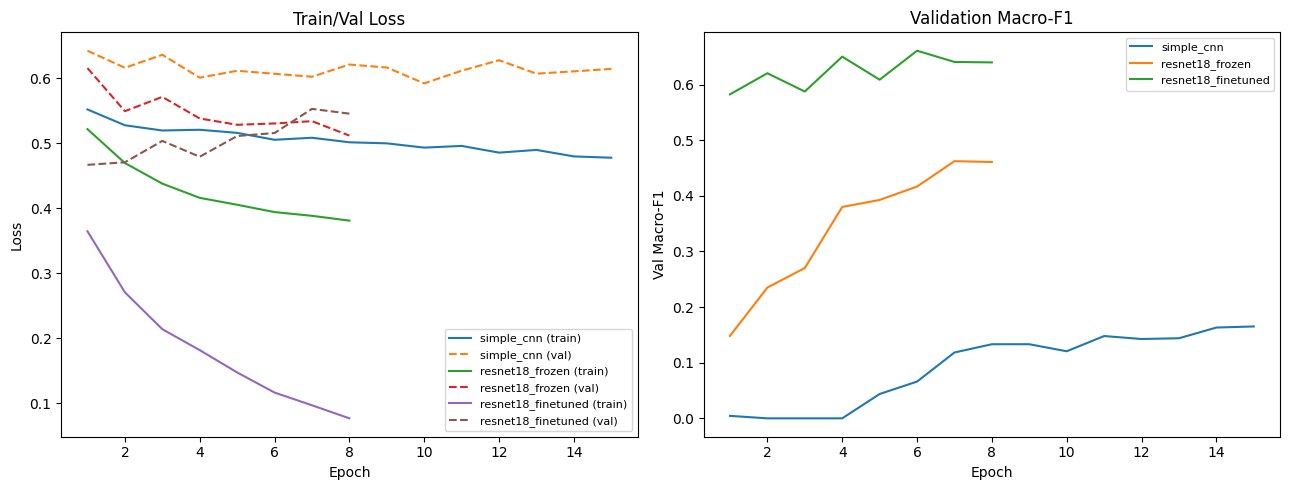

In [ ]:
import matplotlib.pyplot as plt

# reload histories from checkpoints in case kernel was restarted
histories = {}
for name in ["simple_cnn", "resnet18_frozen", "resnet18_finetuned"]:
    ckpt = torch.load(os.path.join(CHECKPOINT_DIR, f"{name}_last.pt"), map_location=device, weights_only=False)
    histories[name] = ckpt["history"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, hist in histories.items():
    epochs = range(1, len(hist["train_loss"]) + 1)
    axes[0].plot(epochs, hist["train_loss"], label=f"{name} (train)")
    axes[0].plot(epochs, hist["val_loss"], linestyle="--", label=f"{name} (val)")
    axes[1].plot(epochs, hist["val_f1"], label=name)

axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title("Train/Val Loss")
axes[0].legend(fontsize=8)

axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Val Macro-F1"); axes[1].set_title("Validation Macro-F1")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "training_curves.png"), dpi=150)
plt.show()

In [ ]:
import os
print(os.path.exists(os.path.join(DATA_DIR, "training_curves.png")))

True
